In [1]:
import os
from xspec import *
import xspec
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.table import Table
from decimal import Decimal
from scipy import optimize, stats
from iminuit import Minuit
from scipy.stats import chi2 as chi2_scipy


Xset.allowPrompting = False # keeps pyxspec from hanging, waiting for a response to a prompt

In [2]:
AllData.clear()
path="/Users/marcotaoso/Documents/2024/eROSITA/FromJorge/LMC_test_3deg/srctoolout_000_SourceProducts_00001_cheesemask_circle_masked/"
#filespectrumTM1=path+"srctoolout_120_SourceSpec_00001.fits"
filespectrumTM1=path+"Rebining_2/srctoolout_120_SourceSpec_00001_2.grp"
fileRMFTM1=path+"srctoolout_120_RMF_00001.fits"
fileARFTM1=path+"srctoolout_120_ARF_00001.fits"
#
#filespectrumTM2=path+"srctoolout_220_SourceSpec_00001.fits"
filespectrumTM2=path+"Rebining_2/srctoolout_220_SourceSpec_00001_2.grp"
fileRMFTM2=path+"srctoolout_220_RMF_00001.fits"
fileARFTM2=path+"srctoolout_220_ARF_00001.fits"
#
#filespectrumTM3=path+"srctoolout_320_SourceSpec_00001.fits"
filespectrumTM3=path+"Rebining_2/srctoolout_320_SourceSpec_00001_2.grp"
fileRMFTM3=path+"srctoolout_320_RMF_00001.fits"
fileARFTM3=path+"srctoolout_320_ARF_00001.fits"
#
filespectrumTM4=path+"srctoolout_420_SourceSpec_00001.fits"
#filespectrumTM4=path+"Rebining_2/srctoolout_420_SourceSpec_00001_2.grp"
fileRMFTM4=path+"srctoolout_420_RMF_00001.fits"
fileARFTM4=path+"srctoolout_420_ARF_00001.fits"
#
#filespectrumTM5=path+"srctoolout_520_SourceSpec_00001.fits"
filespectrumTM5=path+"Rebining_2/srctoolout_520_SourceSpec_00001_2.grp"
fileRMFTM5=path+"srctoolout_520_RMF_00001.fits"
fileARFTM5=path+"srctoolout_520_ARF_00001.fits"
#
#filespectrumTM6=path+"srctoolout_620_SourceSpec_00001.fits"
filespectrumTM6=path+"Rebining_2/srctoolout_620_SourceSpec_00001_2.grp"
fileRMFTM6=path+"srctoolout_620_RMF_00001.fits"
fileARFTM6=path+"srctoolout_620_ARF_00001.fits"
#
#filespectrumTM7=path+"srctoolout_720_SourceSpec_00001.fits"
filespectrumTM7=path+"Rebining_2/srctoolout_720_SourceSpec_00001_2.grp"
fileRMFTM7=path+"srctoolout_720_RMF_00001.fits"
fileARFTM7=path+"srctoolout_720_ARF_00001.fits"
#
#Put here the TM you want to use 
#
vfilespectrum = [filespectrumTM1]#,filespectrumTM2,filespectrumTM3,filespectrumTM4,filespectrumTM6]
vfileRMF = [fileRMFTM1]#,fileRMFTM2,fileRMFTM3,fileRMFTM4,fileRMFTM6]
vfileARF = [fileARFTM1]#,fileARFTM2,fileARFTM3,fileARFTM4,fileARFTM6]
#
#LOAD DATA
#
AllData.clear()
for plot_grp in range (0,len(vfilespectrum)):
    #print("plot_grp ",plot_grp)
    Spectrum(vfilespectrum[plot_grp])
    AllData(plot_grp+1).response = vfileRMF[plot_grp]
    AllData(plot_grp+1).response.arf = vfileARF[plot_grp]

AllData.show()


 response file  read skipped

1 spectrum  in use
 
Spectral Data File: /Users/marcotaoso/Documents/2024/eROSITA/FromJorge/LMC_test_3deg/srctoolout_000_SourceProducts_00001_cheesemask_circle_masked/Rebining_2/srctoolout_120_SourceSpec_00001_2.grp  Spectrum 1
Net count rate (cts/s) for Spectrum:1  1.582e+00 +/- 4.115e-03
 Assigned to Data Group 1 and Plot Group 1
  Noticed Channels:  1-512
  Telescope: eROSITA Instrument: TM1  Channel Type: PI
  Exposure Time: 9.345e+04 sec
 Using fit statistic: chi
 No response loaded.

***Warning!  One or more spectra are missing responses,
               and are not suitable for fit.
Response successfully loaded.
Arf successfully loaded.

1 file 1 spectrum 
Spectrum 1  Spectral Data File: /Users/marcotaoso/Documents/2024/eROSITA/FromJorge/LMC_test_3deg/srctoolout_000_SourceProducts_00001_cheesemask_circle_masked/Rebining_2/srctoolout_120_SourceSpec_00001_2.grp
Net count rate (cts/s) for Spectrum:1  1.582e+00 +/- 4.115e-03
 Assigned to Data Group 1 an

Error: cannot read response file srctoolout_120_RMF_00001.fits


In [3]:
data = np.loadtxt("/Users/marcotaoso/Documents/2024/eROSITA/FromJorge/sigma/Energy_width.txt",delimiter=",")
vE = data[:,0]
vFWHM = data[:,1]*1e-3 #keV
vsigma = vFWHM/(2.355)

In [4]:
# I do not consider eROSITA data outside this range
Eallmin = 0.3
Eallmax = 9.

Eline = 4.771 #0.842

sigma = np.interp(Eline,vE,vsigma)
print("Eline ",Eline," sigma ",sigma)
Emin= Eline - 5*sigma
Emax= Eline + 5*sigma
if(Emin<Eallmin):
    Emin=Eallmin
if(Emax>Eallmax):
    Emax=Eallmax
print("Emin ",Emin," Emax ",Emax)
str_range = "**-"+str(round(Emin, 4))+",,"+str(round(Emax, 4))+"-**"
print(str_range)
AllData.ignore(str_range)


Plot.commands = ()
Plot.xAxis = "keV"
Plot("data")
#ax.clear()
# Compute number of E bins, assumig it is the same for all TM
NEbins = len(np.asarray(Plot.x(1)))
print("NEbins ",NEbins)
venergies = np.zeros((len(vfilespectrum), NEbins))
vedeltas = np.zeros((len(vfilespectrum), NEbins))
vrates = np.zeros((len(vfilespectrum), NEbins))
verrors = np.zeros((len(vfilespectrum), NEbins))
for i in range (0,len(vfilespectrum)):
    plot_grp = i + 1 # so that it starts with 1
    energiesTMi = np.asarray(Plot.x(plot_grp))
    edeltasTMi = np.asarray(Plot.xErr(plot_grp))
    ratesTMi = np.asarray(Plot.y(plot_grp))
    errorsTMi = np.asarray(Plot.yErr(plot_grp))
    venergies[i] = energiesTMi 
    vedeltas[i] = edeltasTMi 
    vrates[i] = ratesTMi 
    verrors[i] = errorsTMi 
    print("***************")
    print("Selected values ",np.min(energiesTMi)," ",np.max(energiesTMi)," Nbins ",len(energiesTMi))
    print("***************")
    channelmin = AllData(plot_grp).noticed[0] -1
    channelmax = AllData(plot_grp).noticed[-1]
    #print("channelmin/max ",channelmin," ",channelmax)
    #
    SpectrumOpen = fits.open(vfilespectrum[plot_grp-1])['SPECTRUM']
    counts_TMi = SpectrumOpen.data.field('COUNTS')#
    channel_TMi = SpectrumOpen.data.field('CHANNEL')#
    exposure_TMi=fits.getval(vfilespectrum[plot_grp-1],"exposure", ext=1)
    RMFOpen = fits.open(vfileRMF[plot_grp-1])['EBOUNDS']
    Emin_data_TMi = RMFOpen.data.field('E_MIN')#keV
    Emax_data_TMi = RMFOpen.data.field('E_MAX')#keV
    Eave_data_TMi = (Emin_data_TMi+Emax_data_TMi)/2.
    DeltaE_data_TMi = Emax_data_TMi-Emin_data_TMi
    DeltaE_ana_TMi = DeltaE_data_TMi[channelmin:channelmax]
    Eave_ana_TMi = Eave_data_TMi[channelmin:channelmax]
    channel_ana_TMi = channel_TMi[channelmin:channelmax]
    counts_ana_TMi = counts_TMi[channelmin:channelmax]
    print("Min Max counts ",np.min(counts_ana_TMi)," ",np.max(counts_ana_TMi))


Eline  4.771  sigma  0.050468744932550026
Emin  4.51865627533725  Emax  5.02334372466275
**-4.5187,,5.0233-**
Plot command list is now empty
NEbins  21
***************
Selected values  4.542070388793945   5.0054402351379395  Nbins  21
***************
   260 channels (1-260) ignored in spectrum #     1
   231 channels (282-512) ignored in spectrum #     1

Min Max counts  92   133


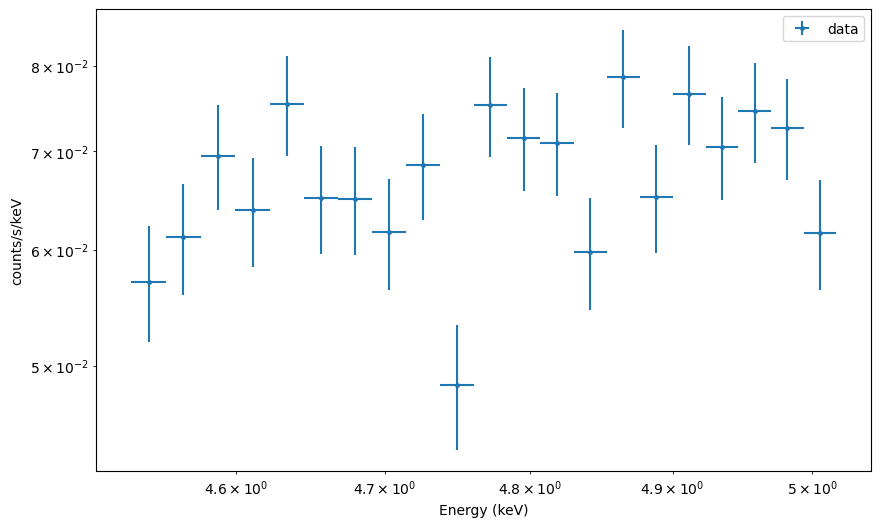

In [5]:
#ax.clear()
fig, ax = plt.subplots(figsize=(10,6))
for i in range (0,len(vfilespectrum)):
    ax.errorbar(venergies[i], vrates[i], xerr=vedeltas[i],yerr=verrors[i],fmt='.',markersize='5',label='data')
#ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

In [6]:
EminL = Eline - 7*sigma
EmaxL = Eline + 7*sigma
if(EminL<Eallmin):
    EminL = Eallmin
if(EmaxL>Eallmax):
    EmaxL = Eallmax

data = np.loadtxt("/Users/marcotaoso/Documents/2024/eROSITA/IB_FWC/IBLines.txt",skiprows=0)
IBenergy = data[:,0]
IBenergymin = data[:,1]
IBenergymax = data[:,2]
data = np.loadtxt("/Users/marcotaoso/Documents/2024/eROSITA/AstroLines/AstroLines.txt",skiprows=0)
Aenergy = data[:,0]
Aenergymin = data[:,1]
Aenergymax = data[:,2]
#print(Aenergy," ",IBenergy)
#print(len(Aenergy)," ",len(IBenergy))
IBidx = np.where( (IBenergy > EminL ) & (IBenergy < EmaxL ) )
Aidx = np.where( (Aenergy > EminL ) & (Aenergy < EmaxL ) )
IBLine = IBenergy[IBidx]
IBLinemin = IBenergymin[IBidx]
IBLinemax = IBenergymax[IBidx]


ALine = Aenergy[Aidx]
#ALinemin = Aenergymin[Aidx]
#ALinemax = Aenergymax[Aidx]
# SET HERE VARIATION OF ASTRO LINE
AstroEl = 0.005;
ALinemin = ALine - AstroEl
ALinemax = ALine + AstroEl


IBn = len(IBLine)
An = len(ALine)
#
# For this model avoid Astro lines
#
IBALine = IBLine.copy()
IBALinemin = IBLinemin.copy()
IBALinemax = IBLinemax.copy()
IBAn = IBn
idx = np.argsort(IBALine)
IBALine = IBALine[idx]
IBALinemin = IBALinemin[idx]
IBALinemax = IBALinemax[idx]
print("Total lines ",IBAn," IB ",IBn," A ",An)
print(IBALine)
print(IBALinemin," ",IBALinemax)

Total lines  1  IB  1  A  0
[4.51187]
[4.49]   [4.53]


In [7]:
# COMPUTE norm of the line to hit data
# to have an idea of a sensible normalization
# For simplicity choose TM1
arf1test = fits.open(fileARFTM1)['SPECRESP']
arf1ELOW = arf1test.data.field('ENERG_LO')#keV
arf1EHI = arf1test.data.field('ENERG_HI')#keV
arf1Aeff = arf1test.data.field('SPECRESP')#cm2
arf1E = (arf1ELOW + arf1EHI)/2.
Aefftest = np.interp(Eline, arf1E, arf1Aeff)
Ratetest = np.interp(Eline, venergies[0], vrates[0])
normlDMhdata = Ratetest/Aefftest # counts/keV/s/cm2
print("normlDMhdata [counts/keV/s/cm2]",normlDMhdata)
# normlDMhdata2 is the correct normalization to set norm of DM gaussian line to a reasonable value! 
# It has the same units of norm of Gaussian
# See nAPEC_Alll.ipynb
normlDMhdata2 = normlDMhdata*np.sqrt(2*np.pi)*sigma # counts/s/cm2
print("normlDMhdata2 [counts/s/cm2]",normlDMhdata2)

normlDMhdata [counts/keV/s/cm2] 0.16658972845104583
normlDMhdata2 [counts/s/cm2] 0.021074663996803106


In [8]:
normline_start= normlDMhdata2*0.01 #*0.01
normline_lower = 0.0
normline_upper = normlDMhdata2*100
sigmaDM = Eline*220/3e5 #1e-4
sigma_astrolines = 1e-4
#
#from the https://github.com/xyzhang/eRASS-spectrum/blob/main/spectral_analysis_basic.ipynb) 
#The foreground Milkyway nH value is cm (https://www.swift.ac.uk/analysis/nhtot/index.php)
startnH = 6.3e-2 #1e22 cm-2 
#uppernH = startnH*100. #*100
#lowernH = startnH*0.01 #*0.01
# do not allow too crazy values
uppernH = 0.7#
lowernH = startnH*0.1
#
# apec https://cxc.cfa.harvard.edu/sherpa/ahelp/xsapec.html
startapec = 0.17 #from the https://github.com/xyzhang/eRASS-spectrum/blob/main/spectral_analysis_basic.ipynb)
#
#if(Eline>1)
#startapec = startapec
#
upperapec = startapec*100.0 #startapec*50.0
lowerapec = 0.0
startT = 0.23 # 0.23keV
upperT = 8.0 # 8keV
lowerT = 0.01 #startT/10.0
startAb = 1.0 # from the https://github.com/xyzhang/eRASS-spectrum/blob/main/spectral_analysis_basic.ipynb)
upperAb = 5.0
lowerAb = 0.01
#
#power law
startidx = 1.4 #1.4
upperidx = 10.0
loweridx = - upperidx
# norm of PL is #/keV/s/cm2 at 1 keV. normlDMhdata is the appropriate quantity to set norm of PL  using formula below (same units!)
# norm * (E/1keV)^(-alpha) = normlDMhdata
#
#startpl = 0.1*normlDMhdata *np.pow(Eline,startidx)
startpl = 0.05
upperpl = startpl*1000.0
lowerpl = 0.0



startidx2 = 3.0 #1.4
upperidx2 = 10.0
loweridx2 = - upperidx2
BreakE = Eline
lower_break = Emin
upper_break = Emax

startapec2 = 0.03
upperapec2 = startapec2*100.0 #startapec*50.0
lowerapec2 = 0.0
startT2 = 0.8 # 0.23keV
upperT2 = 8.0 # 8keV
lowerT2 = 0.01 #startT/10.0
startAb2 = 1.0 # from the https://github.com/xyzhang/eRASS-spectrum/blob/main/spectral_analysis_basic.ipynb)
upperAb2 = 5.0
lowerAb2 = 0.01



fullmodel_xp = Model("powerlaw+gaussian", "mpoly", 1)

#fullmodel_xp = Model("tbabs*(apec+powerlaw+gaussian)", "mpoly", 1)

#fullmodel_xp = Model("tbabs*(apec+bknpower+gaussian)", "mpoly", 1)

#fullmodel_xp = Model("tbabs*(apec+apec+powerlaw+gaussian)", "mpoly", 1)


#fullmodel_xp = Model("apec+powerlaw+gaussian", "mpoly", 1)
#fullmodel_xp = Model("tbabs*(apec+gaussian)+powerlaw", "mpoly", 1)


Model mpoly:powerlaw<1> + gaussian<2> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   powerlaw   PhoIndex            1.00000      +/-  0.0          
   2    1   powerlaw   norm                1.00000      +/-  0.0          
   3    2   gaussian   LineE      keV      6.50000      +/-  0.0          
   4    2   gaussian   Sigma      keV      0.100000     +/-  0.0          
   5    2   gaussian   norm                1.00000      +/-  0.0          
________________________________________________________________________


Fit statistic  : Chi-Squared                  611.31     using 21 bins.

Test statistic : Chi-Squared                  611.31     using 21 bins.
 Null hypothesis probability of 9.12e-120 with 16 degrees of freedom
 Current data and model not fit yet.


In [9]:
#fullmodel_xp.TBabs.nH.values = [float(startnH),float(startnH*0.01),float(lowernH),float(lowernH),float(uppernH),float(uppernH)]

#fullmodel_xp.apec.kT.values = [float(startT),float(startT*0.01),float(lowerT),float(lowerT),float(upperT),float(upperT)]
#fullmodel_xp.apec.norm.values = [float(startapec),float(startapec*0.01),float(lowerapec),float(lowerapec),float(upperapec),float(upperapec)]
#fullmodel_xp.apec.Abundanc = 1.0
#fullmodel_xp.apec.Redshift = 0.0
#fullmodel_xp.apec.Abundanc.frozen = True
#fullmodel_xp.apec.Redshift.frozen = True

fullmodel_xp.powerlaw.norm.values = [float(startpl),float(startpl*0.01),float(lowerpl),float(lowerpl),float(upperpl),float(upperpl)]
fullmodel_xp.powerlaw.PhoIndex.values = [float(startidx),float(startidx*0.01),float(loweridx),float(loweridx),float(upperidx),float(upperidx)]


#fullmodel_xp.bknpower.norm.values = [float(startpl),float(startpl*0.01),float(lowerpl),float(lowerpl),float(upperpl),float(upperpl)]
#fullmodel_xp.bknpower.PhoIndx1.values = [float(startidx),float(startidx*0.01),float(loweridx),float(loweridx),float(upperidx),float(upperidx)]
#fullmodel_xp.bknpower.PhoIndx2.values = [float(startidx2),float(startidx2*0.01),float(loweridx2),float(loweridx2),float(upperidx2),float(upperidx2)]
#fullmodel_xp.bknpower.BreakE.values = [float(BreakE),float(BreakE*0.01),float(lower_break),float(lower_break),float(upper_break),float(upper_break)]


#fullmodel_xp.apec_3.kT.values = [float(startT2),float(startT2*0.01),float(lowerT2),float(lowerT2),float(lowerT2),float(upperT2)]
#fullmodel_xp.apec_3.norm.values = [float(startapec2),float(startapec2*0.01),float(lowerapec2),float(lowerapec2),float(upperapec2),float(upperapec2)]
#fullmodel_xp.apec_3.Abundanc = 1.0
#fullmodel_xp.apec_3.Redshift = 0.0
#fullmodel_xp.apec_3.Abundanc.frozen = True
#fullmodel_xp.apec_3.Redshift.frozen = True


fullmodel_xp.gaussian.norm.values = [0.0,float(normline_start*0.01),float(normline_lower),float(normline_lower),float(normline_upper),float(normline_upper)]
fullmodel_xp.gaussian.Sigma.values = [float(sigmaDM),float(sigmaDM*0.01),float(sigmaDM),float(sigmaDM),float(sigmaDM),float(sigmaDM)]
fullmodel_xp.gaussian.LineE.values = [float(Eline),float(Eline*0.01),float(Eline),float(Eline),float(Eline),float(Eline)]

fullmodel_xp.gaussian.norm.frozen = True
fullmodel_xp.gaussian.Sigma.frozen = True
fullmodel_xp.gaussian.LineE.frozen = True




Fit statistic  : Chi-Squared                 2617.22     using 21 bins.

Test statistic : Chi-Squared                 2617.22     using 21 bins.
 Null hypothesis probability of 0.00e+00 with 16 degrees of freedom
 Current data and model not fit yet.

Fit statistic  : Chi-Squared                 2800.45     using 21 bins.

Test statistic : Chi-Squared                 2800.45     using 21 bins.
 Null hypothesis probability of 0.00e+00 with 16 degrees of freedom
 Current data and model not fit yet.

Fit statistic  : Chi-Squared                 2839.17     using 21 bins.

Test statistic : Chi-Squared                 2839.17     using 21 bins.
 Null hypothesis probability of 0.00e+00 with 16 degrees of freedom
 Current data and model not fit yet.

Fit statistic  : Chi-Squared                 2839.17     using 21 bins.

Test statistic : Chi-Squared                 2839.17     using 21 bins.
 Null hypothesis probability of 0.00e+00 with 16 degrees of freedom
 Current data and model not fit y

In [10]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 1


Parameters defined:
Model mpoly:powerlaw<1> + gaussian<2> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   powerlaw   PhoIndex            1.40000      +/-  0.0          
   2    1   powerlaw   norm                5.00000E-02  +/-  0.0          
   3    2   gaussian   LineE      keV      4.77100      frozen
   4    2   gaussian   Sigma      keV      3.49873E-03  frozen
   5    2   gaussian   norm                0.0          frozen
________________________________________________________________________



In [11]:
'''
print(fullmodel_xp.TBabs.nH.values)
print(fullmodel_xp.apec.kT.values)
print(fullmodel_xp.apec.norm.values)
print(fullmodel_xp.apec.Abundanc.values)
print(fullmodel_xp.apec.Redshift.values)
print(fullmodel_xp.powerlaw.PhoIndex.values)
print(fullmodel_xp.powerlaw.norm.values)
print(fullmodel_xp.gaussian.norm.values)
print(fullmodel_xp.gaussian.LineE.values)
print(fullmodel_xp.gaussian.Sigma.values)
'''

'\nprint(fullmodel_xp.TBabs.nH.values)\nprint(fullmodel_xp.apec.kT.values)\nprint(fullmodel_xp.apec.norm.values)\nprint(fullmodel_xp.apec.Abundanc.values)\nprint(fullmodel_xp.apec.Redshift.values)\nprint(fullmodel_xp.powerlaw.PhoIndex.values)\nprint(fullmodel_xp.powerlaw.norm.values)\nprint(fullmodel_xp.gaussian.norm.values)\nprint(fullmodel_xp.gaussian.LineE.values)\nprint(fullmodel_xp.gaussian.Sigma.values)\n'

In [12]:
print("TS ",Fit.statistic)

TS  2839.174056278845


In [13]:
Fit.statMethod = "cstat"  # fitting statistics = Cash-statistics
Fit.nIterations=100000
Fit.perform()
Fit.perform()
Fit.perform()

In [14]:
Xset.chatter = 10
AllModels.show()
Xset.chatter = 1


Parameters defined:
Model mpoly:powerlaw<1> + gaussian<2> Source No.: 1   Active/On
Model Model Component  Parameter  Unit     Value
 par  comp
   1    1   powerlaw   PhoIndex            -3.41009     +/-  0.622066     
   2    1   powerlaw   norm                7.36977E-04  +/-  7.33713E-04  
   3    2   gaussian   LineE      keV      4.77100      frozen
   4    2   gaussian   Sigma      keV      3.49873E-03  frozen
   5    2   gaussian   norm                0.0          frozen
________________________________________________________________________



In [15]:
Xset.chatter = 10
Fit.show()
Xset.chatter = 1


Fit statistic  : C-Statistic                   32.35     using 21 bins.

Test statistic : Chi-Squared                   35.15     using 21 bins.
 Null hypothesis probability of 1.34e-02 with 19 degrees of freedom


In [16]:
Fit.perform()

Plot command list is now empty


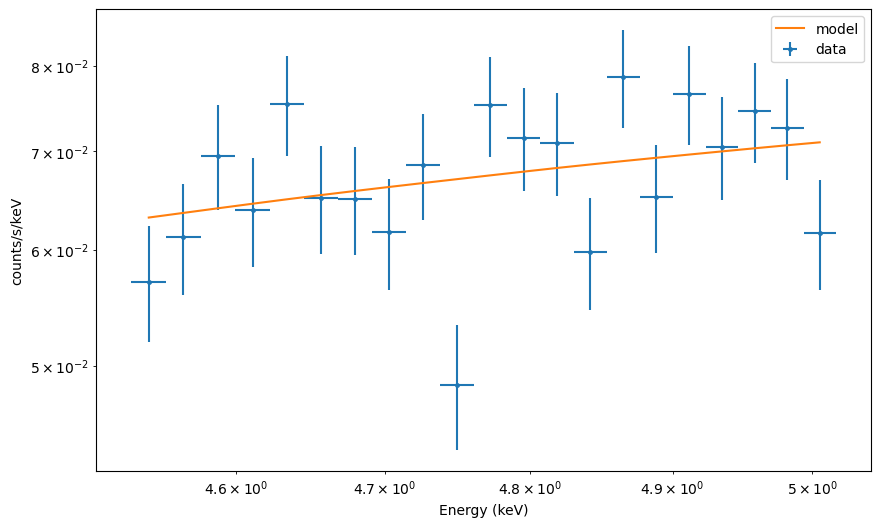

In [17]:
Plot.commands = ()
Plot.xAxis = "keV"
Plot("data")
#ax.clear()

fig, ax = plt.subplots(figsize=(10,6))
for plot_grp in range(1,len(vfilespectrum)+1):
    energies = np.asarray(Plot.x(plot_grp))
    edeltas = np.asarray(Plot.xErr(plot_grp))
    rates = np.asarray(Plot.y(plot_grp))
    errors = np.asarray(Plot.yErr(plot_grp))
    foldedmodel = np.asarray(Plot.model(plot_grp))
    ax.errorbar(energies, rates, xerr=edeltas,yerr=errors,fmt='.',markersize='5',label='data')
    ax.plot(energies, foldedmodel,label='model')

#ax.axhline(y=10)
ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
#ax.set_ylim((0.001,0.1))
ax.grid()
ax.legend()

Plot command list is now empty
nAddComps  2
0
1


IndexError: index 2 is out of bounds for axis 0 with size 2

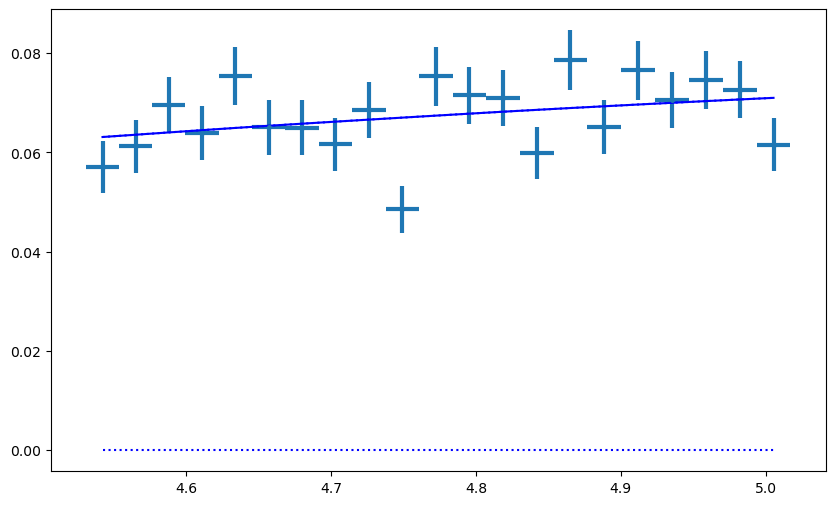

In [18]:
# VALID WHEN I HAVE TABS (MULTIPLICATIVE MODEL)

start_index_astrol = 5

Plot.commands = ()
Plot.add = True
Plot.xAxis = "keV"
Plot("ldata")

# FIX THE TM to plot starting from 1
plot_grp = 1
energiesTMi = np.asarray(Plot.x(plot_grp))
edeltasTMi = np.asarray(Plot.xErr(plot_grp))
ratesTMi = np.asarray(Plot.y(plot_grp))
errorsTMi = np.asarray(Plot.yErr(plot_grp))
foldedmodel = np.asarray(Plot.model(plot_grp))
nAddComps = int(Plot.nAddComps(plot_grp))
print("nAddComps ",nAddComps)

modelcomp = np.zeros((nAddComps, len(energiesTMi)))
modelcomptot = np.zeros(len(energiesTMi))

for i in range(0,nAddComps):
    plot_grp = i + 1 # so that it starts with 1
    #print(i,plot_grp)
    modelcomp[i] = np.asarray(Plot.addComp(plot_grp))
    modelcomptot = modelcomptot + modelcomp[i]

fig, ax = plt.subplots(figsize=(10,6))
ax.errorbar(energiesTMi, ratesTMi, xerr=edeltasTMi,yerr=errorsTMi,fmt='.',markersize='5',label='data',linewidth=3.0)
#ax.plot(energiesTMi, foldedmodel,label='model')
#ax.plot(energiesTMi, modelcomptot,label='model2',linestyle='-', marker='',color='green',linewidth=3.0)

# start_index_astrol is where astro lines start
# -1 because no DM -1 because TAbs is just multiplicative -1 because index i start from 0
index_cont = start_index_astrol-3
model_cont = np.zeros(len(energiesTMi))
for i in range(0,index_cont):
    model_cont = model_cont + modelcomp[i][:]

# Single continous comp
for i in range(0,index_cont):
    print(i)
    ax.plot(energiesTMi, modelcomp[i][:],label='',linestyle=':', marker='',color='blue')

# total continous comp
ax.plot(energiesTMi, model_cont,label='',linestyle='-', marker='',color='blue')


#DM
ax.plot(energiesTMi, modelcomp[index_cont][:],label='',linestyle=':', marker='',color='black')

#Astro lines
for i in range(index_cont+1,nAddComps):
    print(i)
    ax.plot(energiesTMi, modelcomp[i][:],label='',linestyle=':', marker='',color='orange')

ax.plot(energiesTMi, modelcomptot,label='',linestyle='-', marker='',color='green',linewidth=3.0)



ax.set_xlabel('Energy (keV)')
ax.set_ylabel(r'counts/s/keV')
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_ylim(np.min(ratesTMi)*0.01,np.max(ratesTMi)*1.5)
ax.grid()
ax.legend()



In [ ]:
print(modelcomp[0][:])
print(modelcomp[1][:])
print(modelcomp[2][:])